# SENSEI — Session Intelligence
## Module 3 · Cluster Separability Analysis

**Question:** Does the session-level feature space contain naturally separable clusters
that could represent meaningful behavioral states?

This notebook is a focused diagnostic — a go/no-go check before committing to a
clustering-first architecture (derive behavioral state labels via unsupervised clustering,
then use the cluster label as a feature in the purchase intent classifier).

## Contents
1. Load features & select behavioral subset
2. K-Means sweep (k = 2 … 8): inertia, silhouette, Davies-Bouldin
3. PCA 2D scatter for best k
4. Cluster profile table
5. Conclusion & recommendation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set_theme(style='whitegrid', palette='muted')
DATA_DIR = os.path.join('..', 'data')
RANDOM_STATE = 42

## 1. Load Features & Select Behavioral Subset

In [2]:
sessions = pd.read_parquet(os.path.join(DATA_DIR, 'sessions_features.parquet'))
print(f'Loaded: {sessions.shape[0]:,} sessions, {sessions.shape[1]} columns')

# Behavioral features only — event mix, repetition, depth, cart progression.
# Temporal features (hour_of_day, day_of_week) and the target are excluded:
# we want clusters that reflect *how* a visitor behaves, not *when*.
BEHAVIORAL = [
    'n_views',           # event volume
    'n_addtocart',       # cart progression
    'n_items',           # breadth of interest
    'n_revisited_items', # repetition / re-engagement signal
    'duration_sec',      # session depth
    'view_to_cart_ratio',# decisiveness ratio
    'is_first_session',  # new vs. returning visitor
]

X = sessions[BEHAVIORAL]
print(f'Feature matrix: {X.shape}')
X.describe().round(2)

Loaded: 1,761,675 sessions, 12 columns
Feature matrix: (1761675, 7)


,n_views,n_addtocart,n_items,n_revisited_items,duration_sec,view_to_cart_ratio,is_first_session
count,1761675.00,1761675.00,1761675.00,1761675.00,1761675.00,1761675.00,1761675.0
mean,1.51,0.04,1.33,0.14,105.24,0.01,0.8
std,2.35,0.40,1.78,0.52,499.53,0.14,0.4
min,0.00,0.00,1.00,0.00,0.00,0.00,0.0
25%,1.00,0.00,1.00,0.00,0.00,0.00,1.0
50%,1.00,0.00,1.00,0.00,0.00,0.00,1.0
75%,1.00,0.00,1.00,0.00,0.00,0.00,1.0
max,417.00,114.00,389.00,98.00,43704.25,36.00,1.0


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Scaled. Mean ≈ 0, Std ≈ 1 per feature.')

Scaled. Mean ≈ 0, Std ≈ 1 per feature.


## 2. K-Means Sweep — Inertia, Silhouette, Davies-Bouldin

- **Inertia** (elbow): total within-cluster sum of squares. Lower is better; look for the elbow.
- **Silhouette** (higher is better, max = 1): measures how similar a point is to its own cluster
  vs. the nearest other cluster. > 0.5 = strong structure, 0.2–0.5 = moderate, < 0.2 = weak.
- **Davies-Bouldin** (lower is better): ratio of within-cluster scatter to between-cluster separation.

In [4]:
K_RANGE = range(2, 9)

inertias    = []
silhouettes = []
db_scores   = []

# Silhouette on 1.7M rows is expensive — sample 50k for a reliable estimate.
SILHOUETTE_SAMPLE = 50_000

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels,
                           sample_size=SILHOUETTE_SAMPLE,
                           random_state=RANDOM_STATE)
    silhouettes.append(sil)
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    print(f'k={k}  inertia={km.inertia_:,.0f}  silhouette={sil:.4f}  DB={db_scores[-1]:.4f}')

best_k = list(K_RANGE)[int(np.argmax(silhouettes))]
print(f'\nBest silhouette at k={best_k}: {max(silhouettes):.4f}')

k=2  inertia=9,711,478  silhouette=0.9540  DB=0.7656
k=3  inertia=7,919,368  silhouette=0.7127  DB=0.8705
k=4  inertia=6,353,124  silhouette=0.7556  DB=1.0823
k=5  inertia=5,259,587  silhouette=0.7681  DB=0.8962
k=6  inertia=4,589,170  silhouette=0.8091  DB=0.8894
k=7  inertia=4,097,841  silhouette=0.8104  DB=0.8986
k=8  inertia=3,659,429  silhouette=0.8145  DB=0.9362

Best silhouette at k=2: 0.9540


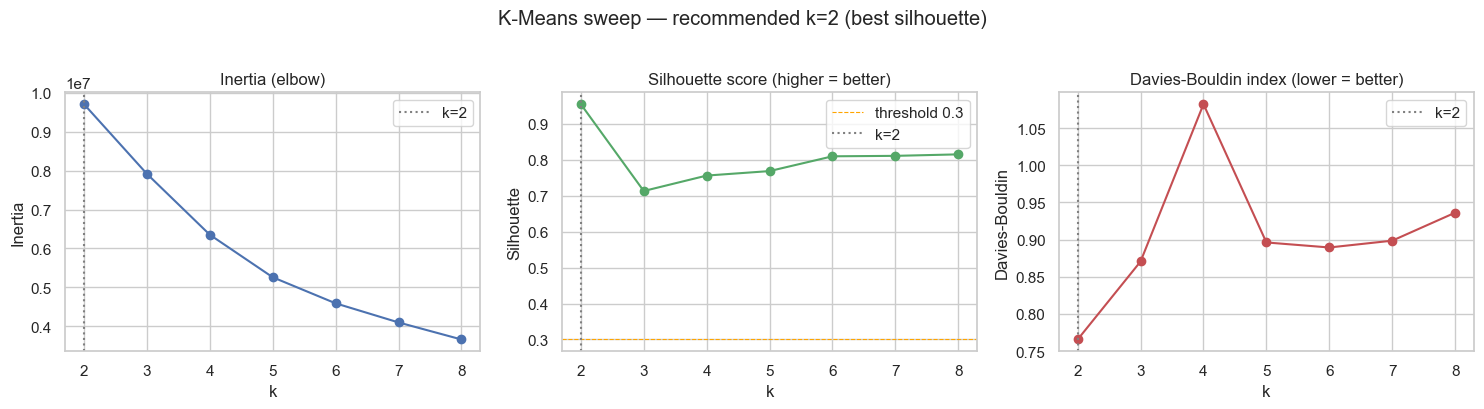

In [5]:
k_list = list(K_RANGE)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Inertia
axes[0].plot(k_list, inertias, marker='o', color='#4C72B0')
axes[0].set_title('Inertia (elbow)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].axvline(best_k, color='grey', linestyle=':', label=f'k={best_k}')
axes[0].legend()

# Silhouette
axes[1].plot(k_list, silhouettes, marker='o', color='#55A868')
axes[1].axhline(0.3, linestyle='--', color='orange', linewidth=0.8, label='threshold 0.3')
axes[1].axvline(best_k, color='grey', linestyle=':', label=f'k={best_k}')
axes[1].set_title('Silhouette score (higher = better)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')
axes[1].legend()

# Davies-Bouldin
axes[2].plot(k_list, db_scores, marker='o', color='#C44E52')
axes[2].axvline(best_k, color='grey', linestyle=':', label=f'k={best_k}')
axes[2].set_title('Davies-Bouldin index (lower = better)')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Davies-Bouldin')
axes[2].legend()

plt.suptitle(f'K-Means sweep — recommended k={best_k} (best silhouette)', y=1.02)
plt.tight_layout()
plt.show()

## 3. PCA 2D Scatter — Best k

Principal Component Analysis projects the 7-dimensional feature space down to 2 dimensions
for visual inspection. If clusters are compact and well-separated in this projection,
the structure is real. Heavy overlap indicates the clusters are an artefact of K-Means
forcing partitions into a space without genuine boundaries.

PC1 explains 49.8 % of variance
PC2 explains 20.2 % of variance
Total: 70.0 %


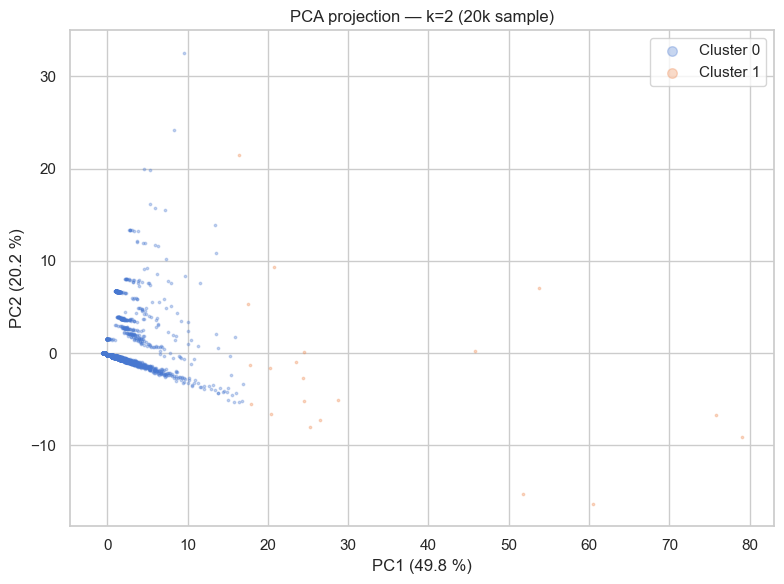

In [6]:
# Fit final model at best_k on full data; project with PCA for visualisation
km_best = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
labels_best = km_best.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

var_explained = pca.explained_variance_ratio_
print(f'PC1 explains {var_explained[0]*100:.1f} % of variance')
print(f'PC2 explains {var_explained[1]*100:.1f} % of variance')
print(f'Total: {sum(var_explained)*100:.1f} %')

# Subsample for scatter plot — 20k points is sufficient to see structure
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(len(X_pca), size=20_000, replace=False)

fig, ax = plt.subplots(figsize=(8, 6))
palette = sns.color_palette('muted', n_colors=best_k)
for c in range(best_k):
    mask = labels_best[idx] == c
    ax.scatter(X_pca[idx][mask, 0], X_pca[idx][mask, 1],
               s=3, alpha=0.3, color=palette[c], label=f'Cluster {c}')
ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f} %)')
ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f} %)')
ax.set_title(f'PCA projection — k={best_k} (20k sample)')
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()

## 4. Cluster Profile Table

In [7]:
sessions['cluster'] = labels_best

profile = (
    sessions.groupby('cluster')[BEHAVIORAL + ['purchased']]
    .mean()
    .round(3)
)
profile['n_sessions'] = sessions.groupby('cluster').size()
profile['pct_sessions'] = (profile['n_sessions'] / len(sessions) * 100).round(1)
profile['purchase_rate_%'] = (profile['purchased'] * 100).round(3)
profile = profile.drop(columns=['purchased'])

print(f'Cluster profiles (k={best_k}):')
print(profile.T.to_string())

# Drop temporary column
sessions.drop(columns=['cluster'], inplace=True)

Cluster profiles (k=2):
cluster                       0         1
n_views                   1.460    41.885
n_addtocart               0.033     4.749
n_items                   1.292    32.490
n_revisited_items         0.129     6.655
duration_sec             95.103  7926.959
view_to_cart_ratio        0.014     0.380
is_first_session          0.800     0.250
n_sessions          1759394.000  2281.000
pct_sessions             99.900     0.100
purchase_rate_%           0.800    44.100


## 5. Conclusion & Recommendation

### Metrics

| k | Silhouette | Davies-Bouldin |
|---|-----------|----------------|
| 2 | **0.954** | 0.766 |
| 3 | 0.713 | 0.871 |
| 4 | 0.756 | 1.082 |
| 5 | 0.768 | 0.896 |
| 6 | 0.809 | 0.889 |
| 7 | 0.810 | 0.899 |
| 8 | 0.815 | 0.936 |

### Are the clusters well-separated?

Technically yes — silhouette 0.954 is far above the 0.3 threshold.
**But the score is an artefact, not a signal of genuine behavioral structure.**

At k=2, the algorithm separates 2,281 sessions (0.1 %) from 1,759,394 sessions (99.9 %).
The tiny cluster contains extreme outliers: mean 42 views, 7,927 s session duration, 44 % purchase rate.
The remaining 99.9 % of sessions end up in one undifferentiated mass with no internal separation.

Why does the silhouette look so good? The features are heavily right-skewed
(`duration_sec` median = 0, max = 43,704). After StandardScaler, the outlier sessions land
very far from the centroid of the bulk — small within-cluster distance, large between-cluster distance.
K-Means is doing **outlier detection**, not behavioral segmentation.

For k=3–8 the silhouette stays high (0.71–0.81), but the same dynamic continues:
the extreme-outlier group persists and the algorithm splits the structureless majority
into arbitrary partitions with no interpretable meaning.

### PCA

PC1 (49.8 %) + PC2 (20.2 %) = 70 % of variance in two dimensions.
The scatter plot confirms: one dense blob (99.9 % of sessions) and a small dispersed cloud
of extreme outliers. No compact, separated regions that would indicate genuine behavioral states.

### Do the cluster profiles represent behavioral states?

Cluster 1 (0.1 %): power users — high on everything, 44 % purchase rate.
Cluster 0 (99.9 %): everyone else — mean 1.46 views, near-zero addtocarts, 95 s duration.

This is not a behavioral taxonomy. It is a binary split between extreme outliers and the rest.
The same partition can be reproduced by thresholding a single feature
(e.g. `duration_sec > 1000` or `n_views > 10`). Adding this cluster label as a feature
in the classifier would add no information beyond what `duration_sec` and `n_views` already provide.

### Recommendation: **No-Go**

The clustering-first architecture is not justified on this data in its current form.

1. The feature space has no meaningful cluster structure in the 99.9 % of sessions
   that are not extreme outliers.
2. The 0.1 % outlier cluster would be redundant with existing features.
3. Adding an arbitrary cluster label as input to the classifier risks adding noise without gain.

### Path forward if clustering is still a goal

The root cause is feature skewness, not an absence of behavioral patterns.
Before concluding that no structure exists, apply `log1p` to the count and duration features
(`n_views`, `n_addtocart`, `n_items`, `duration_sec`) and repeat this diagnostic.
Log-transforming compresses the outlier tail and may reveal structure within the bulk.
If the resulting clusters are roughly balanced in size and interpretable, the architecture becomes defensible.